In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# ==================== 1. 数据加载 ====================
print("="*60)
print("1. 加载 20newsgroups 数据集")
print("="*60)

# 加载训练集和测试集
categories = None  # 使用所有类别
train_data = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
test_data = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

print(f"训练集样本数: {len(train_data.data)}")
print(f"测试集样本数: {len(test_data.data)}")
print(f"类别数: {len(train_data.target_names)}")


1. 加载 20newsgroups 数据集
训练集样本数: 11314
测试集样本数: 7532
类别数: 20


In [3]:
# ==================== 2. 文本特征提取 ====================
print("\n" + "="*60)
print("2. 文本特征提取（构建词索引）")
print("="*60)

# 使用 CountVectorizer 构建词索引（LSTM 需要序列输入）
from sklearn.feature_extraction.text import CountVectorizer

# 构建词表（限制词汇量）
max_features = 20000  # 词汇表大小
max_len = 300  # 序列最大长度

vectorizer = CountVectorizer(
    max_features=max_features,
    stop_words='english',
    lowercase=True,
    token_pattern=r'\b[a-zA-Z]{3,}\b'  # 只保留长度>=3的英文单词
)

# 拟合训练集，构建词表
X_train_counts = vectorizer.fit_transform(train_data.data)
X_test_counts = vectorizer.transform(test_data.data)

# 获取词表映射
word_to_idx = {word: idx + 1 for idx, word in enumerate(vectorizer.get_feature_names_out())}
# 添加 padding 索引 0
word_to_idx['<PAD>'] = 0

print(f"词汇表大小: {len(word_to_idx)}")
print(f"词汇表示例: {list(word_to_idx.items())[:10]}")



2. 文本特征提取（构建词索引）
词汇表大小: 20001
词汇表示例: [('aaa', 1), ('aachen', 2), ('aamir', 3), ('aamrl', 4), ('aardvark', 5), ('aargh', 6), ('aario', 7), ('aaron', 8), ('aau', 9), ('abandon', 10)]


In [4]:
# ==================== 3. 将文本转换为序列 ====================
print("\n" + "="*60)
print("3. 将文本转换为整数序列")
print("="*60)

def text_to_sequence(text, word_to_idx, max_len):
    """将文本转换为整数序列"""
    words = text.lower().split()
    seq = []
    for word in words:
        if word in word_to_idx:
            seq.append(word_to_idx[word])
        # 忽略未登录词
    # 截断或填充
    if len(seq) > max_len:
        seq = seq[:max_len]
    else:
        seq = seq + [0] * (max_len - len(seq))
    return seq

# 转换所有文本
X_train_seq = [text_to_sequence(text, word_to_idx, max_len) for text in train_data.data]
X_test_seq = [text_to_sequence(text, word_to_idx, max_len) for text in test_data.data]

# 转换为 numpy 数组
X_train_seq = np.array(X_train_seq, dtype=np.int64)
X_test_seq = np.array(X_test_seq, dtype=np.int64)

# 标签编码
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_data.target)
y_test = label_encoder.transform(test_data.target)
class_names = train_data.target_names

print(f"训练集序列形状: {X_train_seq.shape}")
print(f"测试集序列形状: {X_test_seq.shape}")
print(f"序列示例: {X_train_seq[0][:20]}...")




3. 将文本转换为整数序列
训练集序列形状: (11314, 300)
测试集序列形状: (7532, 300)
序列示例: [ 2544 18521  3286 12873 19550  5809  2544 15530 16660 10411  9942  5446
  2457  5193 14414  2309 15836 14896 11429  5785]...


In [5]:
# ==================== 4. 数据划分 ====================
print("\n" + "="*60)
print("4. 数据划分")
print("="*60)

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_seq, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"训练集大小: {X_train_part.shape[0]}")
print(f"验证集大小: {X_val.shape[0]}")
print(f"测试集大小: {X_test_seq.shape[0]}")



4. 数据划分
训练集大小: 9051
验证集大小: 2263
测试集大小: 7532


In [6]:
# ==================== 5. 创建 PyTorch 数据加载器 ====================
print("\n" + "="*60)
print("5. 创建数据加载器")
print("="*60)

class NewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

batch_size = 64
train_dataset = NewsDataset(X_train_part, y_train_part)
val_dataset = NewsDataset(X_val, y_val)
test_dataset = NewsDataset(X_test_seq, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练批次数量: {len(train_loader)}")
print(f"验证批次数量: {len(val_loader)}")
print(f"测试批次数量: {len(test_loader)}")



5. 创建数据加载器
训练批次数量: 142
验证批次数量: 36
测试批次数量: 118


In [7]:
# ==================== 6. 定义 LSTM 模型 ====================
print("\n" + "="*60)
print("6. 构建 LSTM 模型")
print("="*60)

class LSTMTextClassifier(nn.Module):
    """
    基于 LSTM 的文本分类器

    架构:
    - Embedding: 将词索引转换为词向量
    - LSTM: 处理序列，提取上下文特征
    - 池化: 聚合所有时间步的信息
    - 全连接: 分类
    """

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, num_classes,
                 dropout=0.5, bidirectional=True):
        """
        Args:
            vocab_size: 词汇表大小
            embedding_dim: 词向量维度
            hidden_dim: LSTM 隐藏层维度
            num_layers: LSTM 层数
            num_classes: 类别数
            dropout: Dropout 比率
            bidirectional: 是否使用双向 LSTM
        """
        super(LSTMTextClassifier, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # 词嵌入层
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # LSTM 层
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        # 计算 LSTM 输出维度
        lstm_output_dim = hidden_dim * (2 if bidirectional else 1)

        # Dropout 层
        self.dropout = nn.Dropout(dropout)

        # 全连接分类层
        self.fc = nn.Linear(lstm_output_dim, num_classes)

    def forward(self, x):
        """
        前向传播

        Args:
            x: (batch_size, seq_len) 输入序列

        Returns:
            output: (batch_size, num_classes) 分类 logits
        """
        # 1. 词嵌入: (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(x)

        # 2. LSTM 处理
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # lstm_out: (batch_size, seq_len, hidden_dim * (2 if bidirectional else 1))
        # hidden: (num_layers * (2 if bidirectional else 1), batch_size, hidden_dim)

        # 3. 取最后一个时间步的隐藏状态
        if self.bidirectional:
            # 双向 LSTM: 取前向和后向的最后一个隐藏状态并拼接
            # hidden[-2] 是前向最后一层，hidden[-1] 是后向最后一层
            last_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        else:
            # 单向 LSTM: 取最后一层的最后一个时间步
            last_hidden = hidden[-1, :, :]

        # 4. Dropout
        last_hidden = self.dropout(last_hidden)

        # 5. 分类
        output = self.fc(last_hidden)

        return output

# 模型参数
vocab_size = len(word_to_idx)  # 词汇表大小
embedding_dim = 128  # 词向量维度
hidden_dim = 128  # LSTM 隐藏层维度
num_layers = 2  # LSTM 层数
num_classes = len(class_names)  # 类别数
dropout = 0.5  # Dropout 比率
bidirectional = True  # 使用双向 LSTM

model = LSTMTextClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=dropout,
    bidirectional=bidirectional
)

print(f"模型结构:")
print(f"  词汇表大小: {vocab_size}")
print(f"  词向量维度: {embedding_dim}")
print(f"  LSTM 隐藏维度: {hidden_dim}")
print(f"  LSTM 层数: {num_layers}")
print(f"  双向: {bidirectional}")
print(f"  输出类别数: {num_classes}")
print(f"  模型参数量: {sum(p.numel() for p in model.parameters()):,}")



6. 构建 LSTM 模型
模型结构:
  词汇表大小: 20001
  词向量维度: 128
  LSTM 隐藏维度: 128
  LSTM 层数: 2
  双向: True
  输出类别数: 20
  模型参数量: 3,224,724


In [8]:
# ==================== 7. 训练配置 ====================
print("\n" + "="*60)
print("7. 训练配置")
print("="*60)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 学习率调度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"使用设备: {device}")



7. 训练配置
使用设备: cuda


In [9]:
# ==================== 8. 训练函数 ====================
def train_epoch(model, loader, criterion, optimizer, device):
    """训练一个 epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # 统计
        total_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    """评估模型"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy, all_preds, all_labels


In [10]:
# ==================== 9. 训练循环 ====================
print("\n" + "="*60)
print("8. 开始训练")
print("="*60)

num_epochs = 20
best_val_acc = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # 训练
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # 验证
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # 调整学习率
    scheduler.step(val_loss)

    # 获取当前学习率
    current_lr = optimizer.param_groups[0]['lr']

    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_lstm_model.pth')

    # 打印进度
    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"LR: {current_lr:.6f}")

print(f"\n训练完成！最佳验证准确率: {best_val_acc:.4f}")



8. 开始训练
Epoch [2/20] Train Loss: 1.7388 | Train Acc: 0.4897 | Val Loss: 1.5420 | Val Acc: 0.5351 | LR: 0.001000
Epoch [4/20] Train Loss: 0.7629 | Train Acc: 0.7812 | Val Loss: 1.1075 | Val Acc: 0.6902 | LR: 0.001000
Epoch [6/20] Train Loss: 0.3908 | Train Acc: 0.8904 | Val Loss: 1.0150 | Val Acc: 0.7269 | LR: 0.001000
Epoch [8/20] Train Loss: 0.2147 | Train Acc: 0.9429 | Val Loss: 1.0916 | Val Acc: 0.7441 | LR: 0.001000
Epoch [10/20] Train Loss: 0.1225 | Train Acc: 0.9677 | Val Loss: 1.1489 | Val Acc: 0.7503 | LR: 0.000500
Epoch [12/20] Train Loss: 0.0438 | Train Acc: 0.9898 | Val Loss: 1.1382 | Val Acc: 0.7768 | LR: 0.000500
Epoch [14/20] Train Loss: 0.0231 | Train Acc: 0.9947 | Val Loss: 1.2173 | Val Acc: 0.7777 | LR: 0.000250
Epoch [16/20] Train Loss: 0.0139 | Train Acc: 0.9972 | Val Loss: 1.2702 | Val Acc: 0.7702 | LR: 0.000250
Epoch [18/20] Train Loss: 0.0093 | Train Acc: 0.9986 | Val Loss: 1.2997 | Val Acc: 0.7782 | LR: 0.000125
Epoch [20/20] Train Loss: 0.0068 | Train Acc: 0.99


9. 可视化训练过程


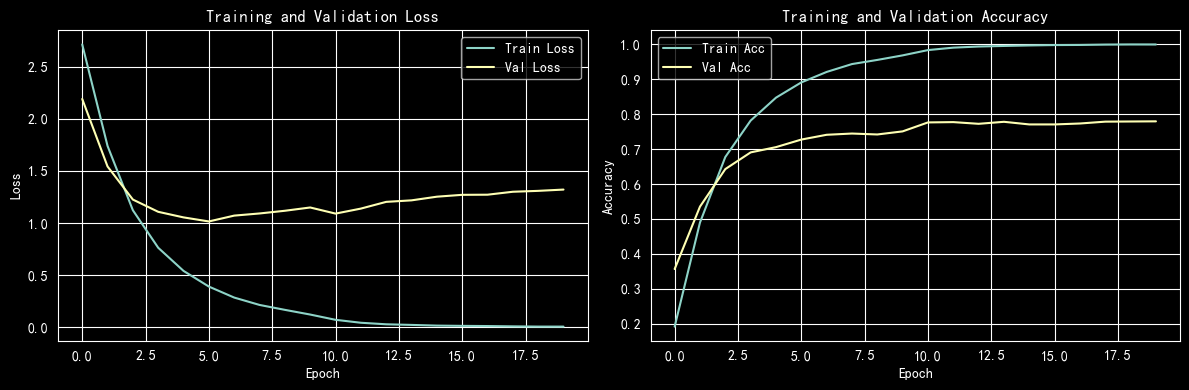

In [11]:
# ==================== 10. 可视化训练过程 ====================
print("\n" + "="*60)
print("9. 可视化训练过程")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# 准确率曲线
axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [12]:
# ==================== 11. 测试集评估 ====================
print("\n" + "="*60)
print("10. 测试集评估")
print("="*60)

# 加载最佳模型
model.load_state_dict(torch.load('best_lstm_model.pth'))

# 在测试集上评估
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print(f"\n测试集结果:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")

# 详细分类报告
print("\n分类报告:")
print(classification_report(test_labels, test_preds,
                            target_names=class_names,
                            digits=4))



10. 测试集评估

测试集结果:
  Loss: 2.3595
  Accuracy: 0.6283

分类报告:
                          precision    recall  f1-score   support

             alt.atheism     0.7148    0.6050    0.6553       319
           comp.graphics     0.5303    0.5167    0.5234       389
 comp.os.ms-windows.misc     0.6284    0.5838    0.6053       394
comp.sys.ibm.pc.hardware     0.5052    0.6148    0.5547       392
   comp.sys.mac.hardware     0.6401    0.6468    0.6434       385
          comp.windows.x     0.6018    0.5089    0.5514       395
            misc.forsale     0.6992    0.6436    0.6702       390
               rec.autos     0.5656    0.5985    0.5816       396
         rec.motorcycles     0.6323    0.7387    0.6813       398
      rec.sport.baseball     0.6587    0.6272    0.6426       397
        rec.sport.hockey     0.7740    0.7895    0.7816       399
               sci.crypt     0.8424    0.7828    0.8115       396
         sci.electronics     0.4349    0.4504    0.4425       393
               


11. 混淆矩阵


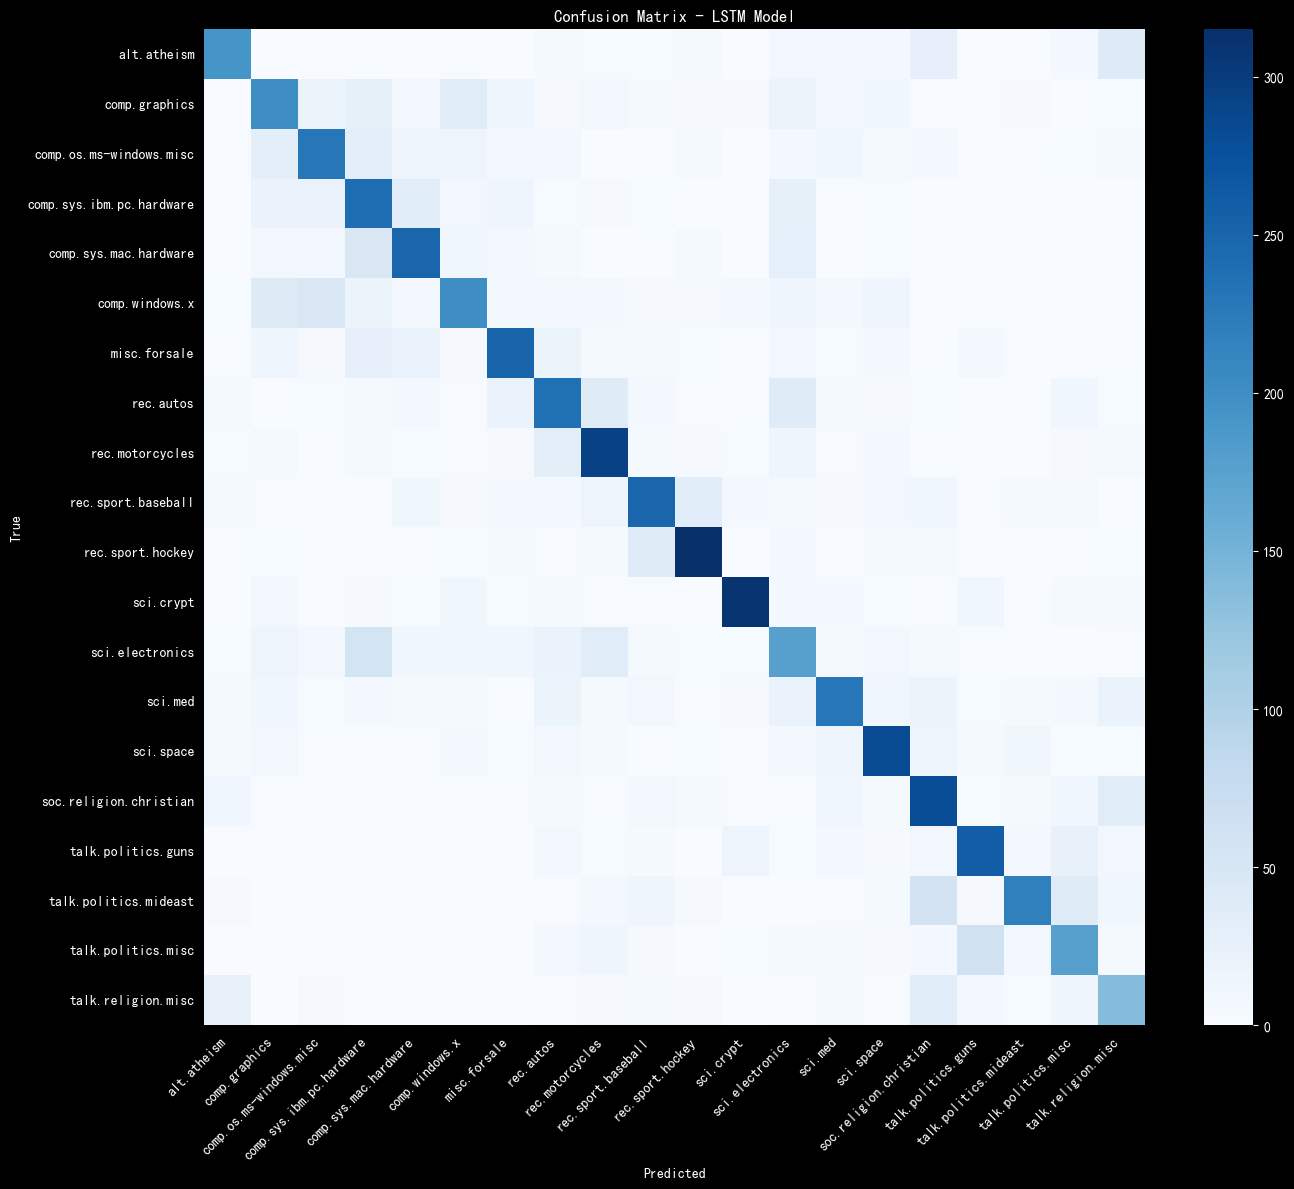

In [13]:
# ==================== 12. 混淆矩阵 ====================
print("\n" + "="*60)
print("11. 混淆矩阵")
print("="*60)

# 计算混淆矩阵
cm = confusion_matrix(test_labels, test_preds)

# 可视化混淆矩阵
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - LSTM Model')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [14]:
# ==================== 13. 推理函数 ====================
print("\n" + "="*60)
print("12. 推理函数示例")
print("="*60)

def predict_text(text, model, word_to_idx, max_len, class_names, device):
    """对单个文本进行预测"""
    model.eval()

    # 转换为序列
    seq = text_to_sequence(text, word_to_idx, max_len)
    seq_tensor = torch.tensor([seq], dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(seq_tensor)
        probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        predicted_idx = np.argmax(probabilities)
        predicted_class = class_names[predicted_idx]

    return predicted_class, probabilities

# 测试推理函数
test_texts = [
    "I love programming in Python and Java. It's so much fun to build software!",
    "The stock market is down today due to economic uncertainty and inflation fears.",
    "The universe is expanding and we are learning more about black holes and galaxies.",
    "Basketball is my favorite sport. I love watching NBA games and playing with friends.",
]

print("推理示例:")
for text in test_texts:
    pred_class, probs = predict_text(text, model, word_to_idx, max_len, class_names, device)
    top_3_idx = np.argsort(probs)[-3:][::-1]
    print(f"\n文本: {text[:80]}...")
    print(f"预测类别: {pred_class}")
    print("Top 3 预测:")
    for idx in top_3_idx[:3]:
        print(f"  {class_names[idx]}: {probs[idx]:.4f}")



12. 推理函数示例
推理示例:

文本: I love programming in Python and Java. It's so much fun to build software!...
预测类别: comp.sys.ibm.pc.hardware
Top 3 预测:
  comp.sys.ibm.pc.hardware: 0.3729
  comp.graphics: 0.2683
  misc.forsale: 0.2175

文本: The stock market is down today due to economic uncertainty and inflation fears....
预测类别: rec.motorcycles
Top 3 预测:
  rec.motorcycles: 0.9863
  rec.sport.baseball: 0.0030
  comp.graphics: 0.0023

文本: The universe is expanding and we are learning more about black holes and galaxie...
预测类别: alt.atheism
Top 3 预测:
  alt.atheism: 0.9748
  rec.sport.hockey: 0.0101
  talk.religion.misc: 0.0063

文本: Basketball is my favorite sport. I love watching NBA games and playing with frie...
预测类别: soc.religion.christian
Top 3 预测:
  soc.religion.christian: 0.4480
  misc.forsale: 0.3351
  rec.sport.hockey: 0.1495



13. LSTM 隐藏状态可视化


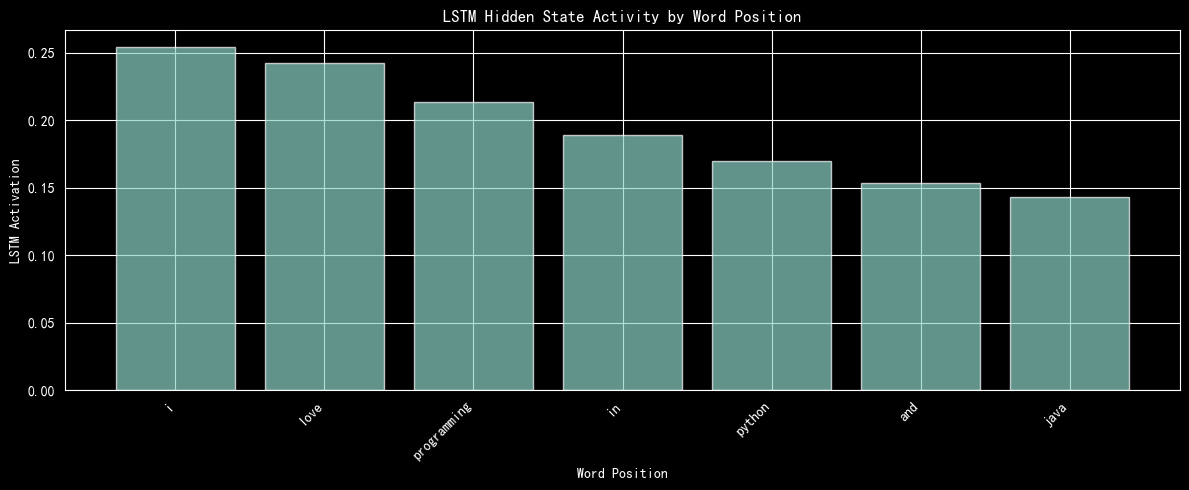


LSTM 文本分类训练完成！


In [15]:
# ==================== 14. 可视化 LSTM 注意力（可选） ====================
print("\n" + "="*60)
print("13. LSTM 隐藏状态可视化")
print("="*60)

def get_lstm_hidden_states(text, model, word_to_idx, max_len, device):
    """获取 LSTM 每个时间步的隐藏状态"""
    model.eval()

    seq = text_to_sequence(text, word_to_idx, max_len)
    seq_tensor = torch.tensor([seq], dtype=torch.long).to(device)

    # 获取词嵌入
    embedded = model.embedding(seq_tensor)

    # 获取 LSTM 输出
    lstm_out, (hidden, cell) = model.lstm(embedded)
    # lstm_out: (1, seq_len, hidden_dim * 2)

    return lstm_out.squeeze(0).cpu().detach().numpy()

# 测试文本
sample_text = "I love programming in Python and Java"
lstm_states = get_lstm_hidden_states(sample_text, model, word_to_idx, max_len, device)

# 计算每个时间步的活跃度（取绝对值均值）
activity = np.mean(np.abs(lstm_states), axis=1)

# 获取实际的词（简单分词）
words = sample_text.lower().split()[:max_len]

plt.figure(figsize=(12, 5))
plt.bar(range(len(words[:len(activity)])), activity[:len(words)], alpha=0.7)
plt.xlabel('Word Position')
plt.ylabel('LSTM Activation')
plt.title('LSTM Hidden State Activity by Word Position')
plt.xticks(range(len(words[:len(activity)])), words[:len(activity)], rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("LSTM 文本分类训练完成！")
print("="*60)